## Inlet Profiles

Chromatographic systems always require some kind of convective flow through the column.

In this lesson, we will:
- Set the Inlet, Outlet, and Flow Sheet up manually.
- Learn about defining events.
- Define inlet profiles using piecewise cubic polynomials.
- Derive inlet profiles from mock experimental data.

### Example 1: Flow from `Inlet` to `Outlet`

In a first example, we will look at a simple system with just two unit operations, an [Inlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Inlet.html), and an [Outlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Outlet.html).

We will introduce flow from the `Inlet` to the `Outlet` with a constant flow rate of $Q = 1~mL \cdot s^{-1}$.
In the first section, the concentration is $1.0~mM$, and after $1~min$, it is changed to $0.0~mM$.

#### 1. Setting up the model

In [1]:
# Component System must to set to insure constance within the system

from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

## Inlet / Feed

## Unit Operations

For an overview of all models in CADET-Process, see [here](https://cadet-process.readthedocs.io/en/v0.11.1/reference/processModel.html#unit-operation-models).

Unit operations require:
- the `ComponentSystem`
- as a unique name.

Note that the name string passed in the constructor is later used to reference the unit in the flow sheet for setting `Events` and `OptimizationVariables`.

In [35]:
from CADETProcess.processModel import Inlet

inlet = Inlet(component_system, 'inlet')
print(inlet.parameters) #Is something missing? Let's check the `parameters` attribute.

{'flow_rate': array([0., 0., 0., 0.]), 'c': array([[0., 0., 0., 0.]])}


In [36]:
inlet.flow_rate = 1e-6

## Outlet
The `Outlet` is another pseudo unit operation that serves as sink for the system (see also [here](https://cadet-process.readthedocs.io/en/v0.11.1/reference/generated/CADETProcess.processModel.Outlet.html#CADETProcess.processModel.Outlet)).

In [37]:
from CADETProcess.processModel import Outlet

outlet = Outlet(component_system, 'outlet')

#### Flow Sheet Connectivity

The `FlowSheet` stores the connectivity between different unit operations.

For more information, see also [here](https://cadet-process.readthedocs.io/en/latest/reference/process_model/flow_sheet.html).

In [38]:
from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system)

flow_sheet.add_unit(inlet)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(inlet, outlet)

## Dynamic Events in Process

Dynamic changes of model parameters or flow sheet connections are configure in `Process` class.

For more information, see also [here](https://cadet-process.readthedocs.io/en/latest/user_guide/process_model/process.html).

In [39]:
from CADETProcess.processModel import Process

process = Process(flow_sheet, 'process')
process.cycle_time = 120

To add an event that changes the value of a parameter, use the `add_event` method which requires the following arguments:
- `name`: Name of the event.
- `parameter_path`: Path of the parameter that is changed in dot notation. E.g. the flow rate of the eluent unit is the parameter `flow_rate` of the `eluent` unit in the `flow_sheet`. Hence, the path is `flow_sheet.eluent.flow_rate`. As previously mentioned, the name of the unit operation is used to reference it, not the variable.
- `state`: Value of the attribute that is changed at Event execution.
- `time`: Time at which the event is executed.

To display all time dependent parameters of an object, use the `section_dependent_parameters` attribute.

In [40]:
print("inlet dependant param:\n", inlet.section_dependent_parameters)
print('flowsheet dependant param:\n', process.flow_sheet.section_dependent_parameters)

inlet dependant param:
 {'flow_rate': array([1.e-06, 0.e+00, 0.e+00, 0.e+00]), 'c': array([[0., 0., 0., 0.]])}
flowsheet dependant param:
 {'inlet': {'flow_rate': array([1.e-06, 0.e+00, 0.e+00, 0.e+00]), 'c': array([[0., 0., 0., 0.]])}, 'output_states': {'inlet': [1.0], 'outlet': {}}, 'outlet': {}}


Note that also flow sheet connectivity can be added as events. More on that later.

In [41]:
_ = process.add_event('start load', 'flow_sheet.inlet.c', [1], 0)
_ = process.add_event('start wash', 'flow_sheet.inlet.c', [0], 60)

All events can are stored in the events attribute. To visualize the trajectory of the parameter state over the entire cycle, the Process provides a `plot_events()` method.

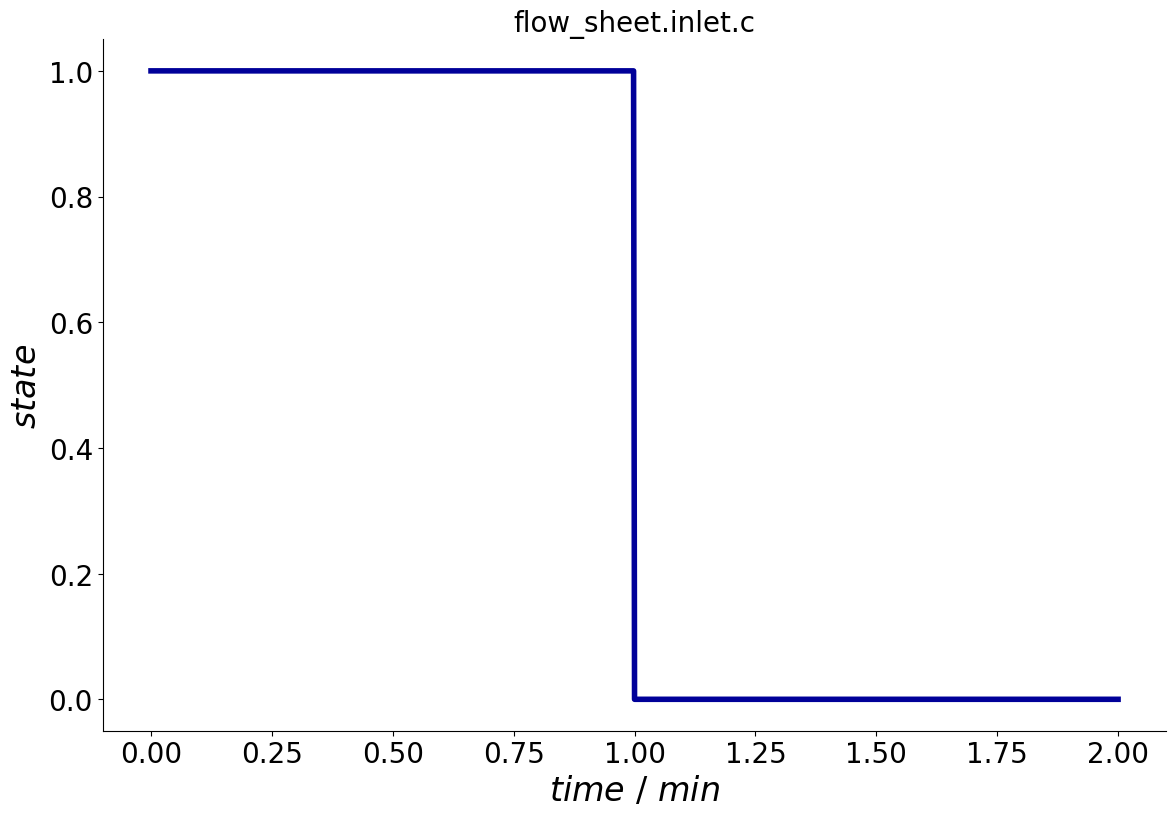

In [42]:
_ = process.plot_events()

## 3. Setting up the simulator and running the simulation

To simulate the process, a process simulator needs to be configured.
If no path is specified, CADET-Process will try to autodetect CADET.

In [43]:
from CADETProcess.simulator import Cadet
process_simulator = Cadet()

if process_simulator.check_cadet():
    simulation_results = process_simulator.simulate(process)
else:
    print("error in set up")

Test simulation completed successfully


## 4. Plotting the results

The simulation_results object contains the solution for the inlet and outlet of every unit operation also provide plot methods.

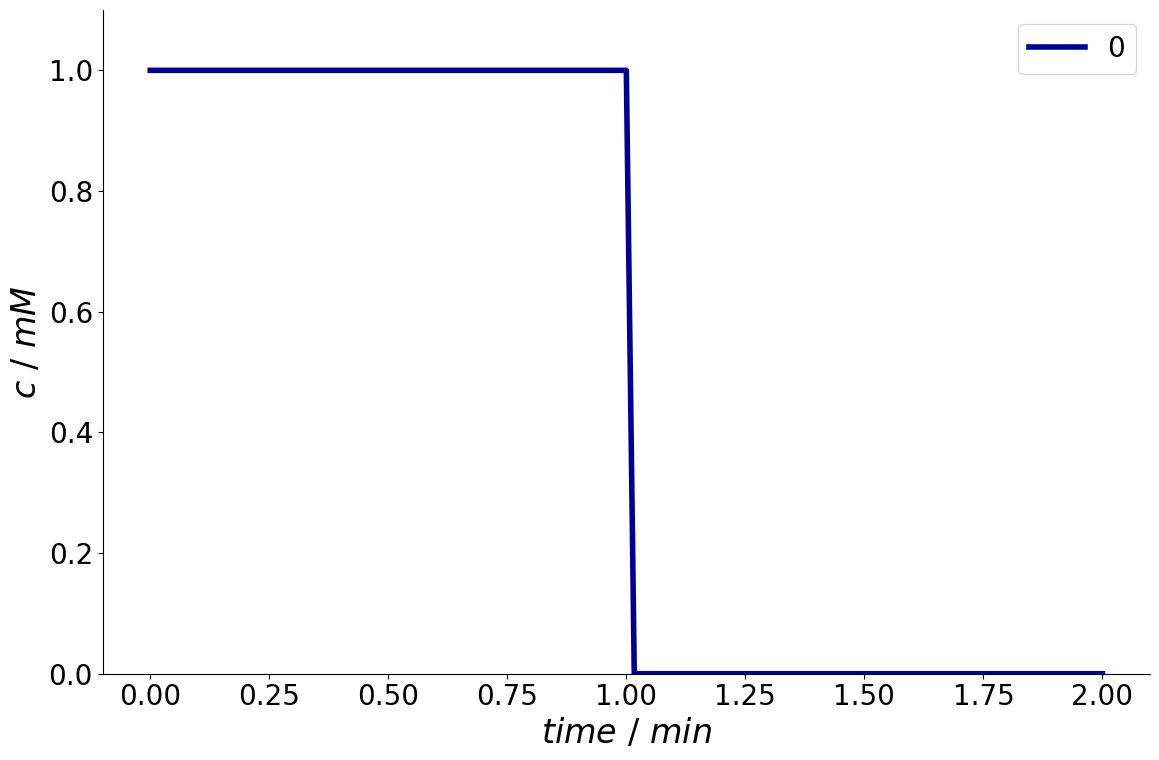

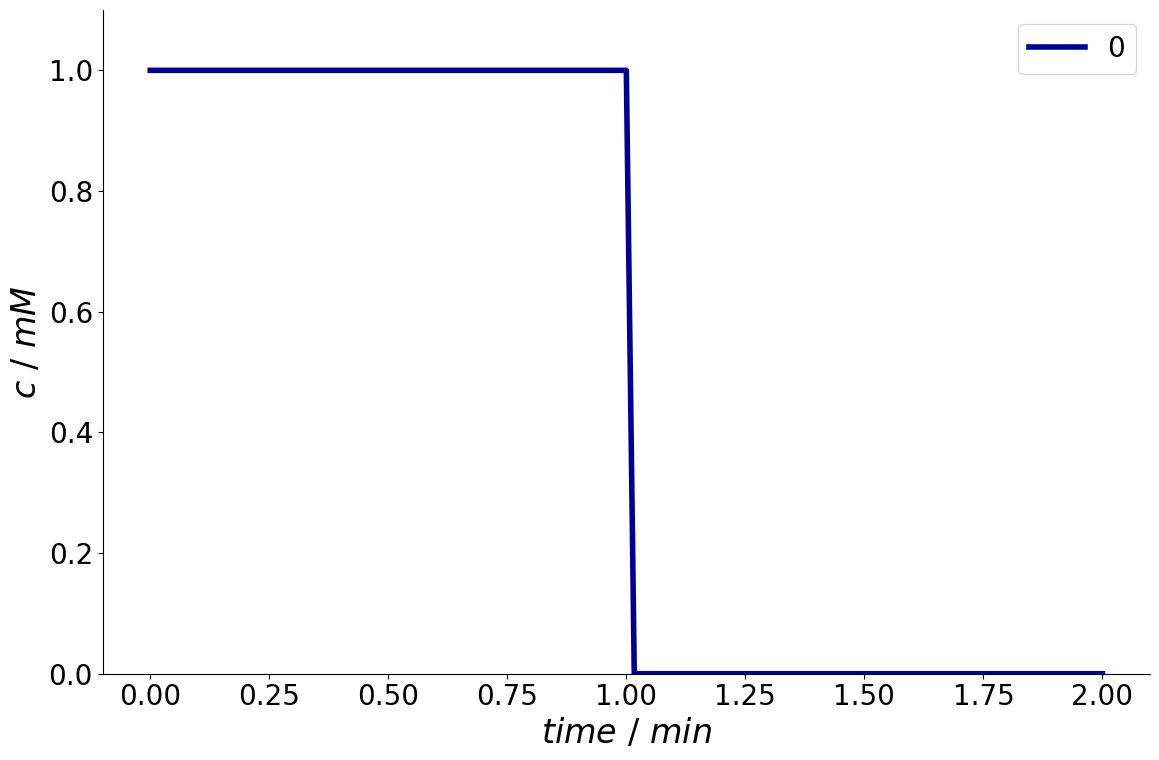

In [ ]:
_ = simulation_results.solution.inlet.outlet.plot()
_ = simulation_results.solution.outlet.outlet.plot()

## 5. Other inlet profiles

Processes may require more complex inlet profiles. CADET-Process allows us to add concentration gradients as high degree polynomials.

E.g. to achieve a concentration gradient from 0 to 1 over 60 s, use a first degree polynomial: $y = a_1\cdot x + a_0$.

General form from $y_0$ to $y_1$ over duration $T$:
$y(t) = y_0 + \dfrac{y_1 - y_0}{T}\cdot t$ for $0 \le t \le T$.


With $y(0)=0$ and $y(60)=1$:
$0 = a_1\cdot 0 + a_0 \Rightarrow a_0 = 0$, $1 = a_1\cdot 60 + 0 \Rightarrow a_1 = 1\cdot 60^{-1}$.

CADET polynomial coefficients: $a_0 = 0$, $a_1 = 1\cdot 60^{-1}$.

In [45]:
# To replace an event you need to remove it first 
process.remove_event('start load')

[<Axes: title={'center': 'flow_sheet.inlet.c'}, xlabel='$time~/~min$', ylabel='$state$'>]

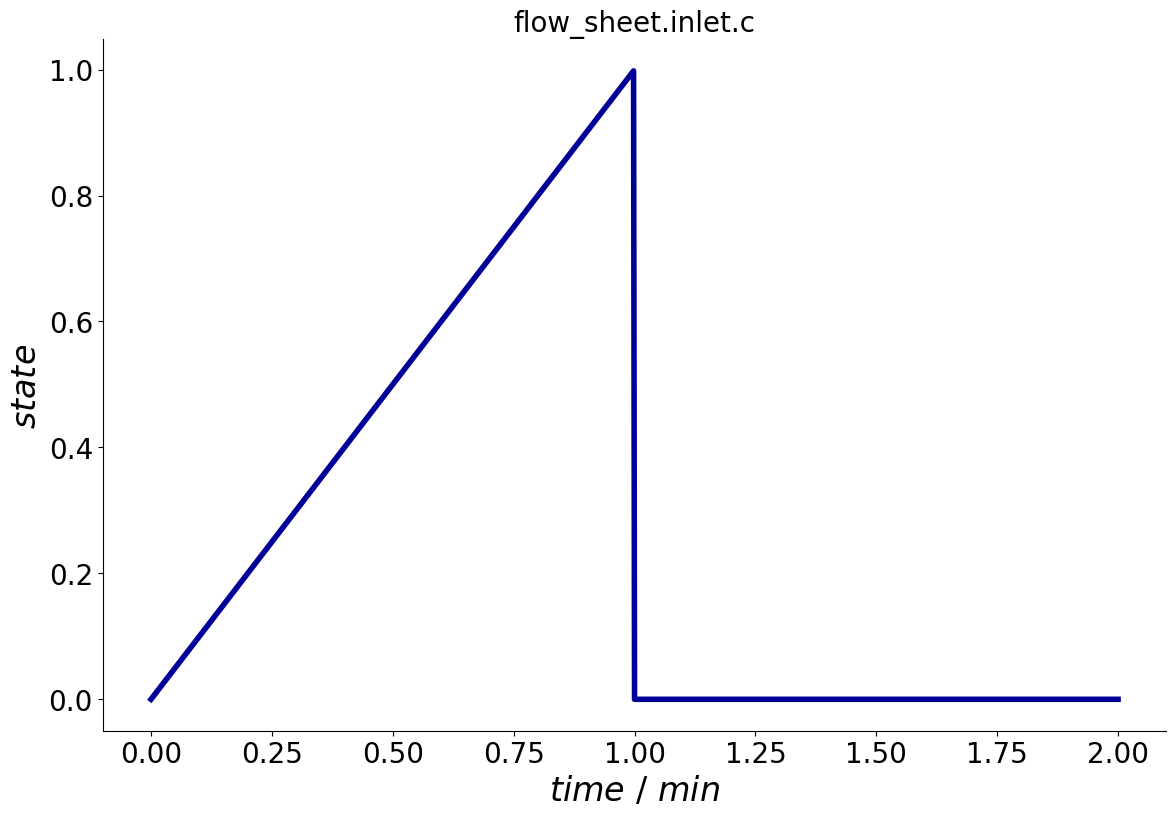

In [46]:
# Then we add the new flow rate as a polynome based on the flow rate we calculated:
process.add_event('start load', 'flow_sheet.inlet.c', [[0,1/60]], 0)
process.plot_events()

When the inlet profile cannot be represented by a polynomial, CADET-Process offers the functionality to add inlet profiles from arrays. 

First let's create a complex simulated inlet profile with some noise:

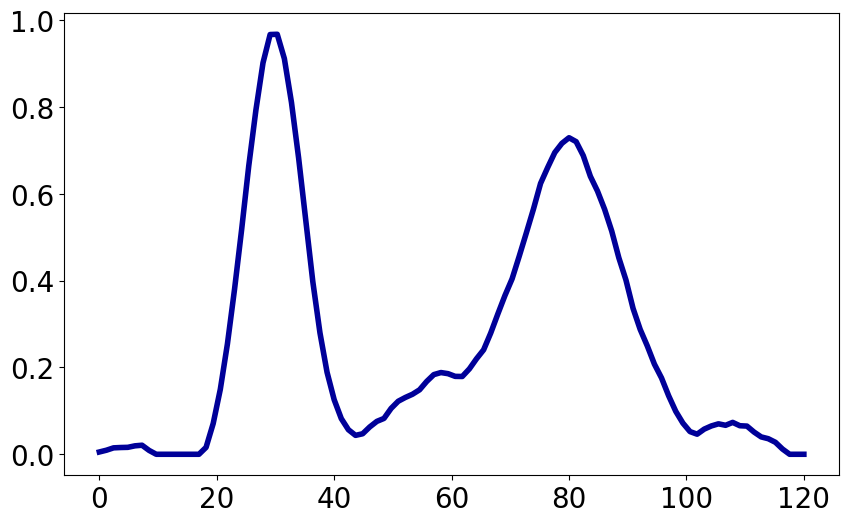

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def noisy_inlet(t, seed=0):
    r = np.random.default_rng(seed)
    s = np.exp(-0.5*((t-30)/5)**2) + 0.7*np.exp(-0.5*((t-80)/9)**2)
    d = 0.03*np.sin(2*np.pi*0.02*t)
    n = r.normal(0, 0.02, t.size)*10
    k = np.exp(-np.abs(np.arange(-15, 16))/5)
    y = np.convolve(n, k, 'same')/k.sum()
    return np.clip(s + d + y, 0, None)

t = np.linspace(0, 120, 100)
c = noisy_inlet(t).reshape(-1,1)

plt.plot(t,c)

Then we remove our old events

In [48]:
process.remove_event('start load')
process.remove_event('start wash')

and add the complext profile, by using the function `add_concentration_profile`, which needs to know the target UO, as well as the time and concentration of the inlet profile.

In [49]:
process.add_concentration_profile('inlet',t,c)

[<Axes: title={'center': 'flow_sheet.inlet.c'}, xlabel='$time~/~min$', ylabel='$state$'>]

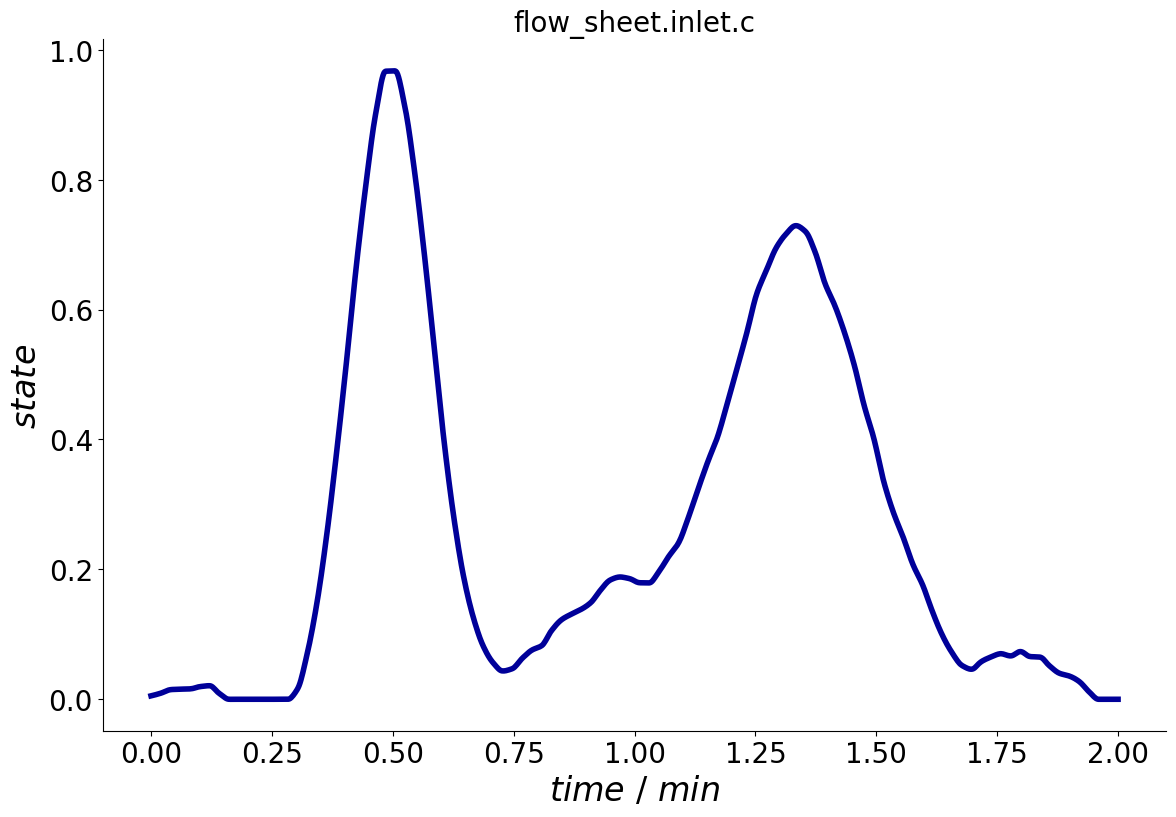

In [50]:
process.plot_events()